# LA Traffic & Air Quality Pipeline

Builds `data/processed/` parquets and `la_traffic_air.duckdb` from raw PeMS and EPA AQS data.

## 1. Setup

In [44]:
import glob
import logging
import zipfile
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# Path setup
RAW       = Path("data/raw")
PROCESSED = Path("data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

PEMS_META   = RAW / "pems" / "d07_text_meta_2023_12_22.txt"
PEMS_HOURLY = sorted(glob.glob(str(RAW / "pems" / "*.txt.gz")))
EPA_HOURLY  = sorted(glob.glob(str(RAW / "epa" / "hourly_*.zip")))
EPA_MONITORS = RAW / "epa" / "aqs_monitors.zip"

DB_PATH = PROCESSED / "la_traffic_air.duckdb"

log.info("PeMS hourly files : %d", len(PEMS_HOURLY))
log.info("EPA  hourly files : %d", len(EPA_HOURLY))

13:08:18  INFO      PeMS hourly files : 24
13:08:18  INFO      EPA  hourly files : 2


## 2. Stations Metadata → `stations.parquet`

Filter to mainline (ML) stations only.

In [2]:
log.info("Loading stations metadata …")

stations = pd.read_csv(PEMS_META, sep="\t", low_memory=False)
log.info("  raw rows: %d", len(stations))

stations = (
    stations
    .rename(columns=lambda c: c.strip())
    .query("Type == 'ML'")
    .rename(columns={"ID": "station_id"})
    [["station_id", "Fwy", "Dir", "District", "County",
      "Latitude", "Longitude", "Type", "Lanes", "Name"]]
    .drop_duplicates(subset="station_id")
    .reset_index(drop=True)
)

out = PROCESSED / "stations.parquet"
stations.to_parquet(out, index=False)
log.info("  saved %d stations → %s", len(stations), out)
stations.head(3)

12:36:05  INFO      Loading stations metadata …
12:36:05  INFO        raw rows: 4888
12:36:05  INFO        saved 1916 stations → data/processed/stations.parquet


,station_id,Fwy,Dir,District,County,Latitude,Longitude,Type,Lanes,Name
0,715898,5,N,7,37,33.880069,-118.021261,ML,3,PHOEBE
1,715915,5,N,7,37,33.924353,-118.084803,ML,3,TINA
2,715916,5,S,7,37,33.924281,-118.084952,ML,3,TINA


## 3. PeMS Hourly Traffic → `traffic.parquet`

Read all monthly `.txt.gz` files, keep ML lane type, drop rows with null `total_flow`.

In [3]:
PEMS_COLS = [
    "Timestamp", "Station", "District", "Freeway", "Direction",
    "Lane Type", "Station Length", "Samples", "% Observed",
    "Total Flow", "Avg Occupancy", "Avg Speed",
]

frames = []
for f in PEMS_HOURLY:
    log.info("  reading %s", Path(f).name)
    chunk = pd.read_csv(
        f,
        compression="gzip",
        header=0,
        usecols=range(len(PEMS_COLS)),
        names=PEMS_COLS,
        low_memory=False,
    )
    frames.append(chunk)

traffic_raw = pd.concat(frames, ignore_index=True)
log.info("combined raw rows: %d", len(traffic_raw))

traffic = (
    traffic_raw
    .rename(columns={
        "Timestamp"   : "timestamp",
        "Station"     : "station_id",
        "Lane Type"   : "lane_type",
        "Total Flow"  : "total_flow",
        "Avg Occupancy": "avg_occupancy",
        "Avg Speed"   : "avg_speed",
        "Samples"     : "samples",
        "% Observed"  : "pct_observed",
    })
    .query("lane_type == 'ML'")
    .dropna(subset=["total_flow"])
    [["timestamp", "station_id", "lane_type",
      "total_flow", "avg_occupancy", "avg_speed",
      "samples", "pct_observed"]]
    .assign(
        timestamp     = lambda d: pd.to_datetime(d["timestamp"]),
        total_flow    = lambda d: pd.to_numeric(d["total_flow"],    errors="coerce"),
        avg_occupancy = lambda d: pd.to_numeric(d["avg_occupancy"], errors="coerce"),
        avg_speed     = lambda d: pd.to_numeric(d["avg_speed"],     errors="coerce"),
    )
    .dropna(subset=["total_flow"])
    .reset_index(drop=True)
)

out = PROCESSED / "traffic.parquet"
traffic.to_parquet(out, index=False)
log.info("saved %d traffic rows → %s", len(traffic), out)
traffic.head(3)

12:36:05  INFO        reading d07_text_station_hour_2024_01.txt.gz
12:36:10  INFO        reading d07_text_station_hour_2024_02.txt.gz
12:36:15  INFO        reading d07_text_station_hour_2024_03.txt.gz
12:36:19  INFO        reading d07_text_station_hour_2024_04.txt.gz
12:36:25  INFO        reading d07_text_station_hour_2024_05.txt.gz
12:36:30  INFO        reading d07_text_station_hour_2024_06.txt.gz
12:36:35  INFO        reading d07_text_station_hour_2024_07.txt.gz
12:36:39  INFO        reading d07_text_station_hour_2024_08.txt.gz
12:36:44  INFO        reading d07_text_station_hour_2024_09.txt.gz
12:36:49  INFO        reading d07_text_station_hour_2024_10.txt.gz
12:36:54  INFO        reading d07_text_station_hour_2024_11.txt.gz
12:36:59  INFO        reading d07_text_station_hour_2024_12.txt.gz
12:37:04  INFO        reading d07_text_station_hour_2025_01.txt.gz
12:37:08  INFO        reading d07_text_station_hour_2025_02.txt.gz
12:37:13  INFO        reading d07_text_station_hour_2025_03.tx

,timestamp,station_id,lane_type,total_flow,avg_occupancy,avg_speed,samples,pct_observed
0,2024-01-01,715915,ML,2036.0,0.0310,69.0,0,0
1,2024-01-01,715916,ML,2036.0,0.0310,69.0,0,0
2,2024-01-01,715918,ML,1560.0,0.0246,68.8,0,0


## 4. EPA AQS Hourly NO₂ → `air_quality.parquet`

Concatenate all `hourly_*.zip` files, filter to California District 7 counties, NO₂ only, drop negative measurements.

In [4]:
D7_COUNTIES = ["Los Angeles", "Ventura"]

aq_frames = []
for f in EPA_HOURLY:
    log.info("  reading %s", Path(f).name)
    with zipfile.ZipFile(f) as z:
        with z.open(z.namelist()[0]) as fh:
            aq_frames.append(pd.read_csv(fh, low_memory=False))

aq_raw = pd.concat(aq_frames, ignore_index=True)
log.info("combined raw rows: %d", len(aq_raw))

air_quality = (
    aq_raw
    .rename(columns=lambda c: c.strip())
    .query("`State Name` == 'California'")
    .query("`County Name` in @D7_COUNTIES")
    .query("`Parameter Name` == 'Nitrogen dioxide (NO2)'")
    .query("`Sample Measurement` >= 0")
    [[
        "Site Num", "County Name", "Latitude", "Longitude",
        "Date Local", "Time Local",
        "Sample Measurement", "Units of Measure", "Parameter Name",
    ]]
    .rename(columns={
        "Site Num"          : "site_num",
        "County Name"       : "county",
        "Date Local"        : "date_local",
        "Time Local"        : "time_local",
        "Sample Measurement": "no2_ppb",
        "Units of Measure"  : "units",
        "Parameter Name"    : "parameter",
    })
    .assign(
        timestamp = lambda d: pd.to_datetime(
            d["date_local"] + " " + d["time_local"],
            errors="coerce"
        )
    )
    .drop(columns=["date_local", "time_local"])
    .dropna(subset=["timestamp"])
    .reset_index(drop=True)
)

out = PROCESSED / "air_quality.parquet"
air_quality.to_parquet(out, index=False)
log.info("saved %d air quality rows → %s", len(air_quality), out)
air_quality.head(3)

12:38:22  INFO        reading hourly_42602_2024.zip
12:38:29  INFO        reading hourly_42602_2025.zip
12:38:33  INFO      combined raw rows: 5725192
12:38:34  INFO      saved 237961 air quality rows → data/processed/air_quality.parquet


,site_num,county,Latitude,Longitude,no2_ppb,units,parameter,timestamp
0,16,Los Angeles,34.14435,-117.85036,1.0,Parts per billion,Nitrogen dioxide (NO2),2024-01-01 00:00:00
1,16,Los Angeles,34.14435,-117.85036,0.7,Parts per billion,Nitrogen dioxide (NO2),2024-01-01 01:00:00
2,16,Los Angeles,34.14435,-117.85036,0.9,Parts per billion,Nitrogen dioxide (NO2),2024-01-01 02:00:00


## 5. EPA AQS Monitors Metadata → `monitors.parquet`

Filter to active NO₂ monitors in CA District 7, deduplicate by location.

In [5]:
log.info("Loading monitors metadata …")

with zipfile.ZipFile(EPA_MONITORS) as z:
    with z.open(z.namelist()[0]) as fh:
        monitors_raw = pd.read_csv(fh, low_memory=False)

log.info("  raw rows: %d", len(monitors_raw))

monitors = (
    monitors_raw
    .rename(columns=lambda c: c.strip())
    .query("`State Name` == 'California'")
    .query("`County Name` in @D7_COUNTIES")
    .query("`Parameter Name` == 'Nitrogen dioxide (NO2)'")
    .assign(
        last_sample = lambda d: pd.to_datetime(d["Last Sample Date"], errors="coerce")
    )
    .query("last_sample > '2023-01-01'")
    [[
        "Site Number", "County Name", "City Name",
        "Latitude", "Longitude",
        "Local Site Name", "Address",
        "First Year of Data", "Last Sample Date",
    ]]
    .rename(columns={
        "Site Number"       : "site_num",
        "County Name"       : "county",
        "City Name"         : "city",
        "Local Site Name"   : "site_name",
        "First Year of Data": "first_year",
        "Last Sample Date"  : "last_sample_date",
    })
    .drop_duplicates(subset=["Latitude", "Longitude"])
    .reset_index(drop=True)
)

out = PROCESSED / "monitors.parquet"
monitors.to_parquet(out, index=False)
log.info("saved %d monitors → %s", len(monitors), out)
monitors.head(3)

12:38:34  INFO      Loading monitors metadata …
12:38:36  INFO        raw rows: 368480
12:38:36  INFO      saved 15 monitors → data/processed/monitors.parquet


,site_num,county,city,Latitude,Longitude,site_name,Address,first_year,last_sample_date
0,16,Los Angeles,Glendora,34.14435,-117.85036,Glendora,"840 LAUREL, GLENDORA",1980.0,2025-09-30
1,113,Los Angeles,West Los Angeles,34.05111,-118.45636,West Los Angeles,"VA HOSPITAL, WEST LOS ANGELES",1984.0,2025-09-30
2,1103,Los Angeles,Los Angeles,34.06659,-118.22688,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES",1980.0,2025-09-30


## 6. Load All Four Tables into DuckDB

In [6]:
con = duckdb.connect(str(DB_PATH))

for tbl, path in [
    ("stations",    PROCESSED / "stations.parquet"),
    ("traffic",     PROCESSED / "traffic.parquet"),
    ("air_quality", PROCESSED / "air_quality.parquet"),
    ("monitors",    PROCESSED / "monitors.parquet"),
]:
    con.execute(f"DROP TABLE IF EXISTS {tbl}")
    con.execute(f"CREATE TABLE {tbl} AS SELECT * FROM read_parquet('{path}')")
    n = con.execute(f"SELECT count(*) FROM {tbl}").fetchone()[0]
    log.info("  %-18s %d rows", tbl, n)

print("Tables in DB:", [r[0] for r in con.execute("SHOW TABLES").fetchall()])

12:38:36  INFO        stations           1916 rows
12:38:38  INFO        traffic            33424788 rows
12:38:38  INFO        air_quality        237961 rows
12:38:38  INFO        monitors           15 rows


Tables in DB: ['air_quality', 'analysis', 'analysis_features', 'monitors', 'station_monitor_mapping', 'stations', 'traffic']


## 7. Spatial Join → `station_monitor_mapping.parquet`

Match each traffic station to its nearest NO₂ monitor. Keep only the single closest monitor per station.

In [7]:
spatial_sql = """
SELECT
    s.station_id,
    s.Latitude   AS station_lat,
    s.Longitude  AS station_lon,
    m.site_num   AS monitor_site_num,
    m.Latitude   AS monitor_lat,
    m.Longitude  AS monitor_lon,
    m.county,
    m.city,
    SQRT(
        POWER((s.Latitude  - m.Latitude)  * 111.0, 2) +
        POWER((s.Longitude - m.Longitude) * 111.0 * COS(RADIANS(s.Latitude)), 2)
    ) AS distance_km
FROM stations s
CROSS JOIN monitors m
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY s.station_id
    ORDER BY distance_km
) = 1
"""

mapping = con.execute(spatial_sql).df()
log.info("spatial join produced %d station-monitor pairs", len(mapping))

out = PROCESSED / "station_monitor_mapping.parquet"
mapping.to_parquet(out, index=False)

con.execute("DROP TABLE IF EXISTS station_monitor_mapping")
con.execute(f"CREATE TABLE station_monitor_mapping AS SELECT * FROM read_parquet('{out}')")
log.info("saved → %s and loaded to DuckDB", out)

mapping.head(3)

12:38:38  INFO      spatial join produced 1916 station-monitor pairs
12:38:38  INFO      saved → data/processed/station_monitor_mapping.parquet and loaded to DuckDB


,station_id,station_lat,station_lon,monitor_site_num,monitor_lat,monitor_lon,county,city,distance_km
0,715929,33.971707,-118.123095,1602,34.01029,-118.06850,Los Angeles,Pico Rivera,6.602959
1,715933,33.981839,-118.130679,1602,34.01029,-118.06850,Los Angeles,Pico Rivera,6.536634
2,716028,34.055167,-118.216535,1103,34.06659,-118.22688,Los Angeles,Los Angeles,1.585179


## 8. Core Analysis Query → `analysis.parquet`

Join traffic readings with their nearest monitor's NO₂ measurement at the same timestamp.

In [8]:
analysis_sql = """
SELECT
    t.timestamp,
    t.station_id,
    t.total_flow,
    t.avg_speed,
    t.avg_occupancy,
    m.station_lat,
    m.station_lon,
    m.monitor_lat,
    m.monitor_lon,
    m.distance_km,
    m.county,
    m.city,
    aq.no2_ppb
FROM traffic t
JOIN station_monitor_mapping m
    ON t.station_id = m.station_id
JOIN air_quality aq
    ON  aq.site_num   = m.monitor_site_num
    AND aq.timestamp  = t.timestamp
ORDER BY t.timestamp, t.station_id
"""

analysis = con.execute(analysis_sql).df()
log.info("analysis result: %d rows", len(analysis))

out = PROCESSED / "analysis.parquet"
analysis.to_parquet(out, index=False)

con.execute("DROP TABLE IF EXISTS analysis")
con.execute(f"CREATE TABLE analysis AS SELECT * FROM read_parquet('{out}')")
log.info("saved → %s and loaded to DuckDB", out)

analysis.head(3)

12:39:08  INFO      analysis result: 32374609 rows
12:39:21  INFO      saved → data/processed/analysis.parquet and loaded to DuckDB


,timestamp,station_id,total_flow,avg_speed,avg_occupancy,station_lat,station_lon,monitor_lat,monitor_lon,distance_km,county,city,no2_ppb
0,2024-01-01,715915,2036.0,69.0,0.0310,33.924353,-118.084803,34.01029,-118.0685,9.656471,Los Angeles,Pico Rivera,18.1
1,2024-01-01,715916,2036.0,69.0,0.0310,33.924281,-118.084952,34.01029,-118.0685,9.666507,Los Angeles,Pico Rivera,18.1
2,2024-01-01,715918,1560.0,68.8,0.0246,33.933110,-118.091005,34.01029,-118.0685,8.814129,Los Angeles,Pico Rivera,18.1


## 9. Query

In [28]:
con = duckdb.connect(str(DB_PATH))


In [31]:
con.execute("""
    SELECT
        MIN(distance_km)                                                    AS min_km,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY distance_km)          AS p25_km,
        PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY distance_km)          AS p50_km,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY distance_km)          AS p75_km,
        PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY distance_km)          AS p90_km,
        MAX(distance_km)                                                    AS max_km
    FROM analysis_features
""").df()

,min_km,p25_km,p50_km,p75_km,p90_km,max_km
0,0.15994,4.462762,6.920222,9.341835,12.621945,43.718011


In [32]:
con.execute("""
    SELECT
        hour,
        AVG(no2_ppb)  AS avg_no2,
        COUNT(*)      AS n
    FROM analysis_features
    WHERE no2_ppb IS NOT NULL
    GROUP BY hour
    ORDER BY hour
""").df()

,hour,avg_no2,n
0,0,14.037558,1367467
1,1,14.537098,1261742
2,2,13.737857,1360791
3,3,13.650867,1367596
4,4,14.609854,1366524
5,5,15.543503,1366912
6,6,16.202134,1361002
7,7,15.957845,1349346
8,8,14.972654,1329800
9,9,13.310452,1315488


In [33]:
con.execute("""
    SELECT
        hour,
        AVG(total_flow)     AS avg_flow,
        AVG(avg_speed)      AS avg_speed,
        AVG(avg_occupancy)  AS avg_occupancy,
        COUNT(*)            AS n
    FROM analysis_features
    WHERE total_flow IS NOT NULL
    GROUP BY hour
    ORDER BY hour
""").df()

,hour,avg_flow,avg_speed,avg_occupancy,n
0,0,1542.874658,67.020437,0.029425,1367467
1,1,1149.318043,66.793372,0.023063,1261742
2,2,933.591868,66.665533,0.019903,1360791
3,3,968.194749,66.722889,0.020749,1367596
4,4,1578.002495,67.282862,0.031482,1366524
5,5,2914.540634,67.246700,0.057275,1366912
6,6,3827.732672,62.032168,0.086216,1361002
7,7,4314.980683,58.449931,0.112132,1349346
8,8,4452.271689,56.852336,0.117582,1329800
9,9,4515.991152,57.548698,0.108984,1315488


In [35]:
# Check for missing joins in traffic, air_quality, and analysis tables

matches_traffic = con.execute("""
    SELECT COUNT(*) FROM traffic t
    LEFT JOIN stations s ON t.station_id = s.station_id
    WHERE s.station_id IS NULL
""").fetchone()[0]
print(f"Traffic rows with no matching station: {matches_traffic:,}")


match_aq = con.execute("""
    SELECT COUNT(*) FROM air_quality aq
    LEFT JOIN monitors m ON aq.site_num = m.site_num
    WHERE m.site_num IS NULL
""").fetchone()[0]
print(f"Air quality rows with no matching monitor: {match_aq:,}")


match_analysis = con.execute("""
    SELECT COUNT(*) FROM analysis a
    LEFT JOIN station_monitor_mapping sm ON a.station_id = sm.station_id
    WHERE sm.station_id IS NULL
""").fetchone()[0]
print(f"Analysis rows with no matching mapping: {match_analysis:,}")


Traffic rows with no matching station: 0
Air quality rows with no matching monitor: 0
Analysis rows with no matching mapping: 0


In [36]:
print(f"\nImpossible traffic values:")
print(con.execute("""
    SELECT 
        SUM(CASE WHEN total_flow < 0 THEN 1 ELSE 0 END) as negative_flow,
        SUM(CASE WHEN avg_speed < 0 THEN 1 ELSE 0 END) as negative_speed,
        SUM(CASE WHEN avg_speed > 100 THEN 1 ELSE 0 END) as speed_over_100,
        SUM(CASE WHEN avg_occupancy < 0 THEN 1 ELSE 0 END) as negative_occupancy,
        SUM(CASE WHEN avg_occupancy > 1 THEN 1 ELSE 0 END) as occupancy_over_1
    FROM traffic
""").df().to_string(index=False))


Impossible traffic values:
 negative_flow  negative_speed  speed_over_100  negative_occupancy  occupancy_over_1
           0.0             0.0             0.0                 0.0               0.0


In [12]:
print(f"\nNO2 range in analysis:")
print(con.execute("""
    SELECT 
        MIN(no2_ppb) as min_no2,
        MAX(no2_ppb) as max_no2,
        AVG(no2_ppb) as avg_no2,
        SUM(CASE WHEN no2_ppb < 0 THEN 1 ELSE 0 END) as negative_no2
    FROM analysis
""").df().to_string(index=False))


NO2 range in analysis:
 min_no2  max_no2   avg_no2  negative_no2
     0.0     80.0 12.398388           0.0


## 10. Modeling 

In [16]:
# Add time features to analysis
con.execute("""
    CREATE OR REPLACE TABLE analysis_features AS
    SELECT 
        *,
        HOUR(timestamp) as hour,
        DAYOFWEEK(timestamp) as day_of_week,
        MONTH(timestamp) as month,
        YEAR(timestamp) as year
    FROM analysis
""")

print("Features added")
print(con.execute("SELECT * FROM analysis_features LIMIT 3").df())

Features added
   timestamp  station_id  total_flow  avg_speed  avg_occupancy  station_lat  \
0 2024-01-01      715915      2036.0       69.0         0.0310    33.924353   
1 2024-01-01      715916      2036.0       69.0         0.0310    33.924281   
2 2024-01-01      715918      1560.0       68.8         0.0246    33.933110   

   station_lon  monitor_lat  monitor_lon  distance_km       county  \
0  -118.084803     34.01029    -118.0685     9.656471  Los Angeles   
1  -118.084952     34.01029    -118.0685     9.666507  Los Angeles   
2  -118.091005     34.01029    -118.0685     8.814129  Los Angeles   

          city  no2_ppb  hour  day_of_week  month  year  
0  Pico Rivera     18.1     0            1      1  2024  
1  Pico Rivera     18.1     0            1      1  2024  
2  Pico Rivera     18.1     0            1      1  2024  


In [17]:
print(con.execute("DESCRIBE analysis_features").df())

      column_name column_type null   key default extra
0       timestamp   TIMESTAMP  YES  None    None  None
1      station_id      BIGINT  YES  None    None  None
2      total_flow      DOUBLE  YES  None    None  None
3       avg_speed      DOUBLE  YES  None    None  None
4   avg_occupancy      DOUBLE  YES  None    None  None
5     station_lat      DOUBLE  YES  None    None  None
6     station_lon      DOUBLE  YES  None    None  None
7     monitor_lat      DOUBLE  YES  None    None  None
8     monitor_lon      DOUBLE  YES  None    None  None
9     distance_km      DOUBLE  YES  None    None  None
10         county     VARCHAR  YES  None    None  None
11           city     VARCHAR  YES  None    None  None
12        no2_ppb      DOUBLE  YES  None    None  None
13           hour      BIGINT  YES  None    None  None
14    day_of_week      BIGINT  YES  None    None  None
15          month      BIGINT  YES  None    None  None
16           year      BIGINT  YES  None    None  None


In [37]:
# model dataframe
model_df = con.execute("""
    SELECT
        -- Temporal
        timestamp,
        hour, day_of_week, month, year,

        -- Spatial / contextual (baseline model features)
        station_id,
        station_lat, station_lon,
        monitor_lat, monitor_lon,
        distance_km,
        county, city,

        -- Traffic (features of interest)
        total_flow, avg_speed, avg_occupancy,

        -- Target
        no2_ppb

    FROM analysis_features
    WHERE no2_ppb       IS NOT NULL
      AND total_flow     IS NOT NULL
      AND avg_speed      IS NOT NULL
      AND avg_occupancy  IS NOT NULL
      AND distance_km    IS NOT NULL

""").df()

print(f"Model dataset: {len(model_df):,} rows")
print(model_df.describe())

Model dataset: 32,345,537 rows
                        timestamp          hour   day_of_week         month  \
count                    32345537  3.234554e+07  3.234554e+07  3.234554e+07   
mean   2024-11-16 09:31:51.855524  1.154675e+01  2.988508e+00  5.860477e+00   
min           2024-01-01 00:00:00  0.000000e+00  0.000000e+00  1.000000e+00   
25%           2024-06-08 15:00:00  6.000000e+00  1.000000e+00  3.000000e+00   
50%           2024-11-17 23:00:00  1.200000e+01  3.000000e+00  6.000000e+00   
75%           2025-04-25 21:00:00  1.800000e+01  5.000000e+00  8.000000e+00   
max           2025-09-30 23:00:00  2.300000e+01  6.000000e+00  1.200000e+01   
std                           NaN  6.937721e+00  2.005875e+00  3.200433e+00   

               year    station_id   station_lat   station_lon   monitor_lat  \
count  3.234554e+07  3.234554e+07  3.234554e+07  3.234554e+07  3.234554e+07   
mean   2.024431e+03  7.445464e+05  3.406431e+01 -1.182512e+02  3.407053e+01   
min    2.024000e+03 

In [38]:
# Filter
model_df = model_df[
    (model_df['distance_km'] <= 1) & # keep only station-monitor pairs within 1 km
    (model_df['no2_ppb'] > 0) # no2 of 0 suggests non-detect
].copy()

print(f"Rows after filtering: {len(model_df):,}")

Rows after filtering: 425,929


In [39]:
model_df = model_df.drop_duplicates(subset=['station_id', 'timestamp'])
print(f"Rows after dedup: {len(model_df):,}")

Rows after dedup: 396,039


In [40]:
# Aggregate daytime traffic 6am-8pm
daytime = model_df[model_df['hour'].between(6, 20)].copy()
daytime['date'] = daytime['timestamp'].dt.date

day_agg = (
    daytime.groupby(['station_id', 'date'])
    .agg(
        avg_flow=('total_flow', 'mean'),
        avg_speed=('avg_speed', 'mean'),
        avg_occupancy=('avg_occupancy', 'mean'),
        station_lat=('station_lat', 'first'),
        station_lon=('station_lon', 'first'),
        monitor_lat=('monitor_lat', 'first'),
        monitor_lon=('monitor_lon', 'first'),
        county=('county', 'first'),
    )
    .reset_index()
)

# Aggregate nighttime NO2 12am-4am
nighttime = model_df[model_df['hour'].between(0, 4)].copy()
nighttime['date'] = nighttime['timestamp'].dt.date

night_agg = (
    nighttime.groupby(['station_id', 'date'])
    .agg(avg_no2=('no2_ppb', 'mean'))
    .reset_index()
)

# Lag join: previous day's daytime predicts following night's NO2 
day_agg['date'] = pd.to_datetime(day_agg['date'])
night_agg['date'] = pd.to_datetime(night_agg['date'])

day_agg['night_date'] = day_agg['date'] + pd.Timedelta(days=1)

merged_df = day_agg.merge(
    night_agg.rename(columns={'date': 'night_date'}),
    on=['station_id', 'night_date'],
    how='inner'
)

# Temporal features from nighttime date
merged_df['day_of_week'] = merged_df['night_date'].dt.dayofweek
merged_df['month'] = merged_df['night_date'].dt.month
merged_df['year'] = merged_df['night_date'].dt.year

print(f"Rows: {len(merged_df):,}")
print(f"Unique stations: {merged_df['station_id'].nunique()}")

# Check correlations
print("\nCorrelations with avg_no2:")
print(merged_df[['avg_flow', 'avg_speed', 'avg_occupancy', 'avg_no2']].corr()['avg_no2'].drop('avg_no2').round(4))


Rows: 16,965
Unique stations: 27

Correlations with avg_no2:
avg_flow         0.1075
avg_speed       -0.1663
avg_occupancy    0.1652
Name: avg_no2, dtype: float64


In [41]:
le = LabelEncoder()
merged_df['county_enc'] = le.fit_transform(merged_df['county'].fillna('Unknown'))

merged_df.describe()

,station_id,date,avg_flow,avg_speed,avg_occupancy,station_lat,station_lon,monitor_lat,monitor_lon,night_date,avg_no2,day_of_week,month,year,county_enc
count,16965.000000,16965,16965.000000,16965.000000,16965.000000,16965.000000,16965.000000,16965.000000,16965.000000,16965,16965.000000,16965.000000,16965.000000,16965.000000,16965.000000
mean,734149.720601,2024-11-13 20:39:30,4709.369193,55.041679,0.124219,34.105211,-118.351110,34.103081,-118.354005,2024-11-14 20:39:30.716180,12.566553,3.000884,5.897377,2024.424934,0.325199
min,716819.000000,2024-01-01 00:00:00,120.000000,3.626667,0.001500,33.861086,-118.691694,33.859662,-118.683685,2024-01-02 00:00:00,1.000000,0.000000,1.000000,2024.000000,0.000000
25%,717558.000000,2024-06-06 00:00:00,3577.133333,45.093333,0.063493,34.009316,-118.679194,34.010290,-118.683685,2024-06-07 00:00:00,5.720000,1.000000,3.000000,2024.000000,0.000000
50%,717924.000000,2024-11-11 00:00:00,4752.800000,59.586667,0.106340,34.056927,-118.449662,34.051110,-118.456360,2024-11-12 00:00:00,9.820000,3.000000,6.000000,2024.000000,0.000000
75%,764021.000000,2025-04-25 00:00:00,6181.733333,63.493333,0.186733,34.281460,-118.064134,34.276316,-118.068500,2025-04-26 00:00:00,18.475000,5.000000,8.000000,2025.000000,1.000000
max,775156.000000,2025-09-29 00:00:00,9684.000000,74.826667,0.359820,34.281773,-117.753926,34.276316,-117.751400,2025-09-30 00:00:00,53.100000,6.000000,12.000000,2025.000000,1.000000
std,23562.644851,NaN,1736.692618,10.229789,0.068379,0.132469,0.293890,0.130242,0.293269,NaN,8.781984,2.006723,3.163660,0.494348,0.468463


In [42]:
# Split off testing data

X = merged_df[['avg_flow', 'avg_speed', 'avg_occupancy', 
                'station_lat', 'station_lon', 'monitor_lat', 'monitor_lon',
                'day_of_week', 'month', 'year', 'county_enc']]
y = merged_df['avg_no2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} rows")
print(f"Test : {len(X_test):,} rows")

Train: 13,572 rows
Test : 3,393 rows


In [45]:
# Perform cross-validated grid search for Random Forest on training data
param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(random_state=42, n_jobs=-1, bootstrap=True)

t0 = pd.Timestamp.now()
print("Running GridSearchCV — 810 fits...")

search = GridSearchCV(
    rf,
    param_grid=param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

t1 = pd.Timestamp.now()
print(f"\nDone in {(t1 - t0).seconds // 60}m {(t1 - t0).seconds % 60}s")
print(f"Best CV r2  : {search.best_score_:.4f}")
print(f"Best params : {search.best_params_}")

Running GridSearchCV — 810 fits...
Fitting 5 folds for each of 162 candidates, totalling 810 fits


/Users/evamaiwinston/ds4320/project1env/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/evamaiwinston/ds4320/project1env/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/evamaiwinston/ds4320/project1env/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/evamaiwinston/d


Done in 3m 24s
Best CV r2  : 0.4539
Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


In [46]:
# Use best params on test data
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Set Evaluation")
print(f"r2   : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} ppb")

Test Set Evaluation
r2   : 0.4494
RMSE : 6.6025 ppb


In [47]:
# Feature importance
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance of RF model")
print(importance.round(4))

Feature Importance of RF model
month            0.3561
station_lon      0.1383
monitor_lon      0.1043
avg_flow         0.0759
avg_occupancy    0.0648
avg_speed        0.0636
station_lat      0.0556
county_enc       0.0430
monitor_lat      0.0411
day_of_week      0.0365
year             0.0209
dtype: float64


## 11. Visualize

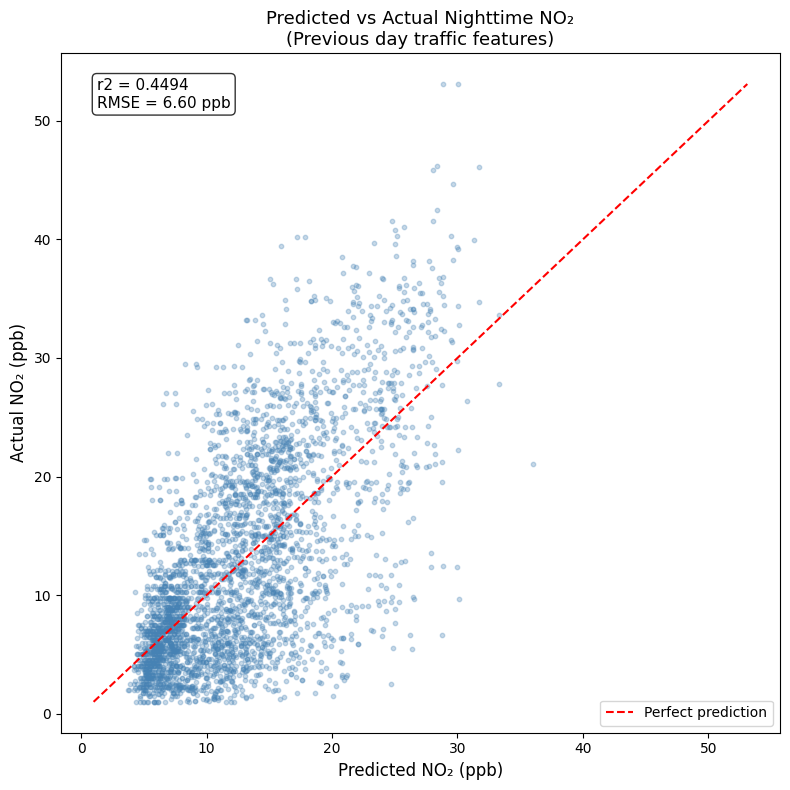

In [48]:
# Predicted vs Actual plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_pred, y_test, alpha=0.3, s=10, color='steelblue')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Predicted NO₂ (ppb)', fontsize=12)
ax.set_ylabel('Actual NO₂ (ppb)', fontsize=12)
ax.set_title('Predicted vs Actual Nighttime NO₂\n(Previous day traffic features)', fontsize=13)
ax.legend()
ax.text(0.05, 0.92, f'r2 = {r2_score(y_test, y_pred):.4f}\nRMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} ppb',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

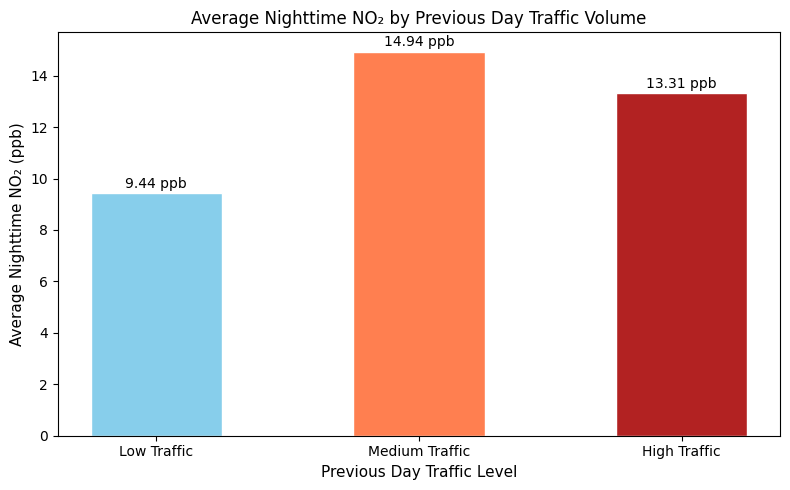

In [49]:
# Traffic bins vs NO2 plot
fig, ax = plt.subplots(figsize=(8, 5))

merged_df['flow_bin'] = pd.qcut(merged_df['avg_flow'], q=3, labels=['Low Traffic', 'Medium Traffic', 'High Traffic'])

bin_means = merged_df.groupby('flow_bin')['avg_no2'].mean()

ax.bar(bin_means.index, bin_means.values, color=['skyblue', 'coral', 'firebrick'], edgecolor='white', width=0.5)

ax.set_title('Average Nighttime NO₂ by Previous Day Traffic Volume', fontsize=12)
ax.set_xlabel('Previous Day Traffic Level', fontsize=11)
ax.set_ylabel('Average Nighttime NO₂ (ppb)', fontsize=11)

for i, (idx, val) in enumerate(bin_means.items()):
    ax.text(i, val + 0.2, f'{val:.2f} ppb', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

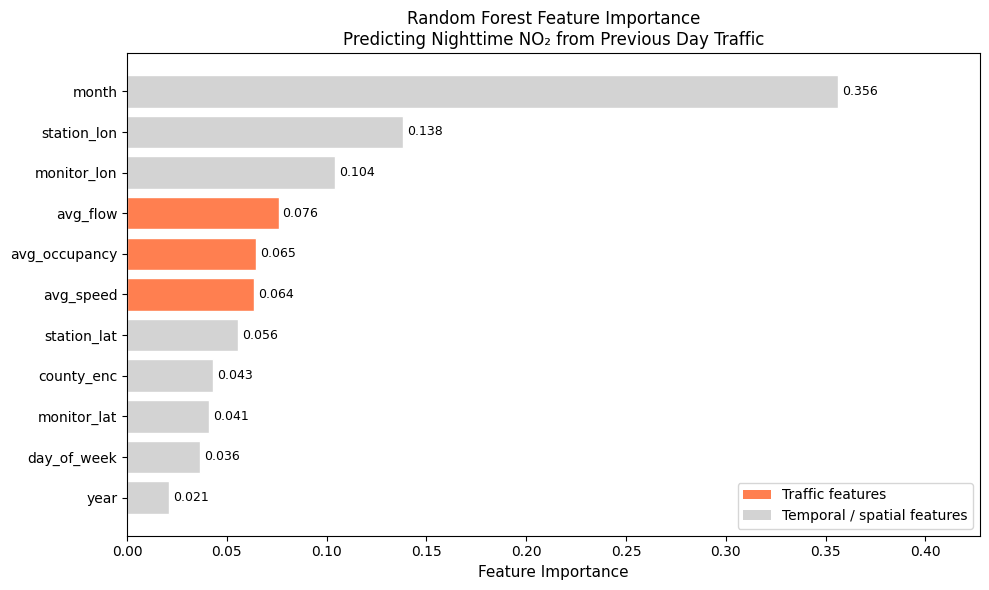

In [50]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 6))

importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

colors = ['coral' if col in ['avg_flow', 'avg_speed', 'avg_occupancy'] 
          else 'lightgray' for col in importance.index]

ax.barh(importance.index, importance.values, color=colors, edgecolor='white')

ax.set_title('Random Forest Feature Importance\nPredicting Nighttime NO₂ from Previous Day Traffic', fontsize=12)
ax.set_xlabel('Feature Importance', fontsize=11)

# Fix cutoff by extending x axis limit
ax.set_xlim(0, importance.values.max() * 1.2)

for i, val in enumerate(importance.values):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='coral', label='Traffic features'),
                   Patch(facecolor='lightgray', label='Temporal / spatial features')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()